In [7]:
import matplotlib.pyplot as plt
import numpy as np

from epilink import EpiLink, InfectiousnessToTransmission, NaturalHistoryParameters

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (8, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "figure.titlesize": 18,
    }
)


rng_seed = 2026

In [17]:
parameters = NaturalHistoryParameters()
profile = InfectiousnessToTransmission(parameters=parameters, rng_seed=rng_seed)

epilink = EpiLink(
    transmission_profile=profile,
    maximum_depth=5,
    target= ["ad(0)", "ca(0,0)"],
    mutation_process="stochastic",
)

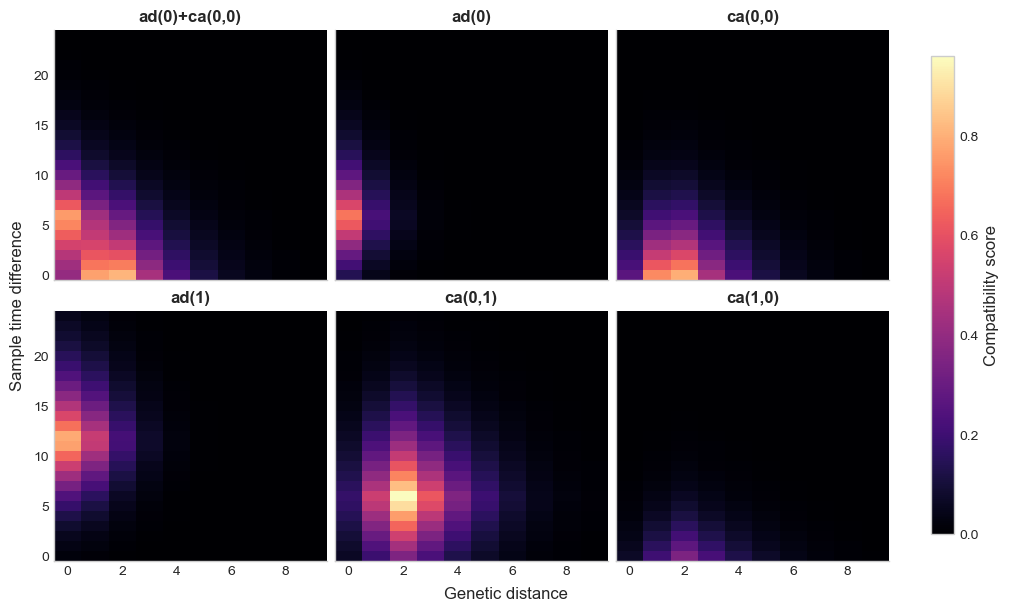

In [19]:
sample_time_difference = np.arange(25)
genetic_distance = np.arange(10)

models = [
    epilink.pairwise_model(),
    epilink.pairwise_model("ad(0)"),
    epilink.pairwise_model("ca(0,0)"),
    epilink.pairwise_model("ad(1)"),
    epilink.pairwise_model("ca(0,1)"),
    epilink.pairwise_model("ca(1,0)"),
]

# Compute all score matrices first so we can use one shared colour scale
metrics = []
for model in models:
    metric = np.zeros((sample_time_difference.size, genetic_distance.size))
    for t, sample_time in enumerate(sample_time_difference):
        for g, genetic in enumerate(genetic_distance):
            metric[t, g] = model.score(sample_time, genetic)
    metrics.append(metric)

vmin = min(m.min() for m in metrics)
vmax = max(m.max() for m in metrics)

# Grid for contours
time_grid, genetic_grid = np.meshgrid(
    sample_time_difference,
    genetic_distance,
    indexing="ij"
)

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True, constrained_layout=True)
im = None  # To store the last image for the colourbar
for ax, model, metric in zip(axes.flat, models, metrics):
    im = ax.imshow(
        metric,
        origin="lower",
        aspect="auto",
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
    )

    # contours = ax.contour(
    #     genetic_grid,
    #     time_grid,
    #     metric,
    #     levels=6,
    #     colors="white",
    #     linewidths=0.7,
    #     alpha=0.8,
    # )
    # ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")

    ax.set_title("+".join(model.target_labels))
    ax.grid(False)

    im = im

# One shared colourbar for all panels
cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label("Compatibility score")

fig.supxlabel("Genetic distance")
fig.supylabel("Sample time difference")
plt.show()